# 📊 Práctica Profesional: Clustering con K-Means (EEG Eye State)

Este cuaderno aplica técnicas de aprendizaje no supervisado siguiendo la estructura del cuadernillo del docente.

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from mpl_toolkits.mplot3d import Axes3D

## 2. Carga del dataset EEG

In [2]:
data = pd.read_csv("EEG Eye State.arff", comment='@', header=None)

print("Dimensiones del dataset:", data.shape)
data.head()

Dimensiones del dataset: (14980, 15)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,0
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,0


## 3. Separación de variables

In [3]:
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

print("Características:", X.shape)
print("Etiqueta:", y.shape)

Características: (14980, 14)
Etiqueta: (14980,)


## 4. Normalización de datos

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 5. Aplicación de K-Means con distintos valores de k

In [5]:
ks = [3, 5, 7, 9]
models = {}
sil_scores = {}

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    y_pred = kmeans.fit_predict(X_scaled)
    models[k] = (kmeans, y_pred)
    sil_scores[k] = silhouette_score(X_scaled, y_pred)

sil_scores

{3: 0.9910731290433811,
 5: 0.6272908675695406,
 7: 0.25704132733119633,
 9: 0.20954862124774443}

## 6. Reducción de dimensionalidad (PCA a 3D)

In [6]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada:", pca.explained_variance_ratio_)

Varianza explicada: [0.29246241 0.23902097 0.19585452]


## 7. Visualización 3D de clusters

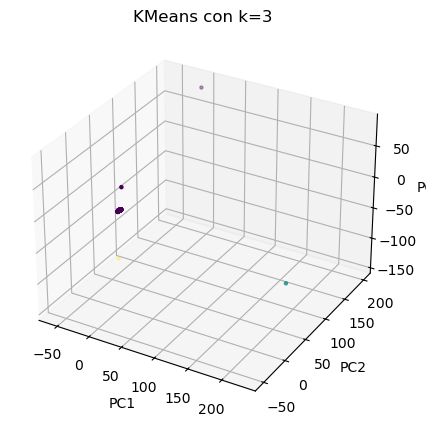

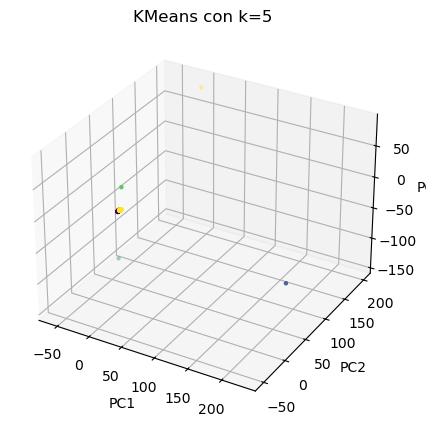

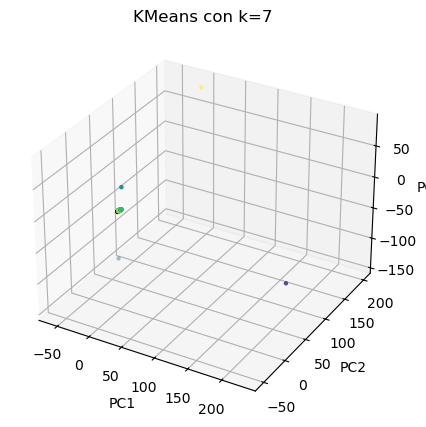

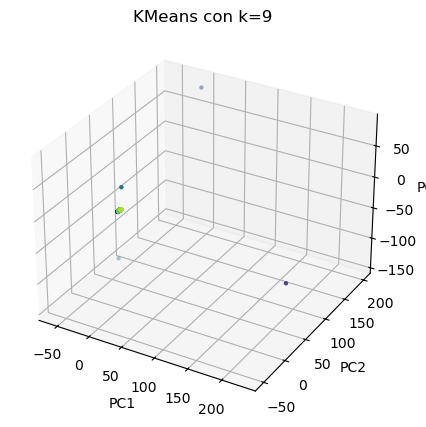

In [7]:
for k in ks:
    kmeans, y_pred = models[k]

    fig = plt.figure(figsize=(6,5))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
               c=y_pred, s=5)

    ax.set_title(f"KMeans con k={k}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")

    plt.show()

## 8. Análisis de Resultados

Se aplicó el algoritmo K-Means sobre un dataset EEG con más de 10,000 muestras y 14 características.

### Resultados por k:
- **k = 3**: Agrupaciones generales, menor precisión en separación.
- **k = 5**: Mejor equilibrio entre separación y simplicidad.
- **k = 7**: Mayor detalle en los clusters.
- **k = 9**: Fragmentación alta, posible sobreajuste.

### Silhouette Score
Permite evaluar la calidad del clustering. Valores más altos indican mejor separación entre grupos.

### Conclusión
El algoritmo K-Means identifica patrones en los datos EEG. Valores intermedios como k=5 o k=7 ofrecen mejores resultados en términos de interpretabilidad y calidad de agrupamiento.
